In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [2]:
customer_df = pd.read_csv(
    "../data/processed/customer_features.csv",
    index_col=0
)

customer_df.head()

,Recency,Frequency,Monetary,avg_delivery_days,avg_delivery_delay,avg_review_score,avg_installments,avg_freight,avg_order_value,repeat_purchase
customer_unique_id,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,6.0,-5.0,5.0,8.0,12.00,141.90,0
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3.0,-5.0,4.0,1.0,8.29,27.19,0
0000f46a3911fa3c0805444483337064,537,1,86.22,25.0,-2.0,3.0,8.0,17.22,86.22,0
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,20.0,-12.0,4.0,4.0,17.63,43.62,0
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,13.0,-8.0,5.0,6.0,16.89,196.89,0


In [3]:
cluster_features = customer_df[
    ["Recency", "Frequency", "Monetary"]
]

In [4]:
cluster_features.describe()

,Recency,Frequency,Monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


In [5]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    cluster_features
)

In [6]:
rfm_scaled.shape

(93358, 3)

In [7]:
inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

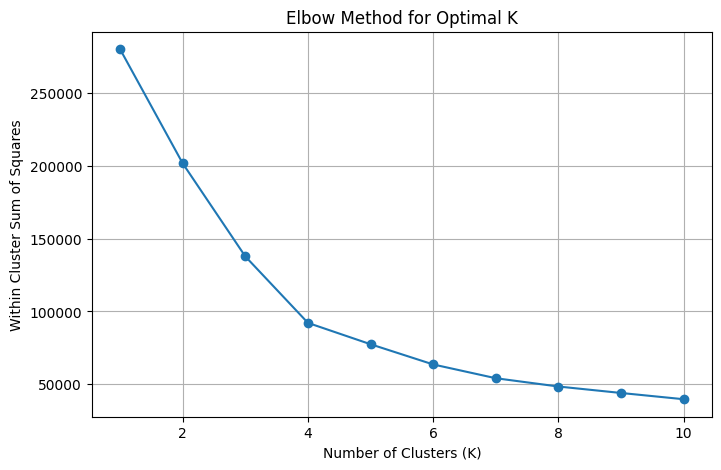

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Sum of Squares")
plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.show()

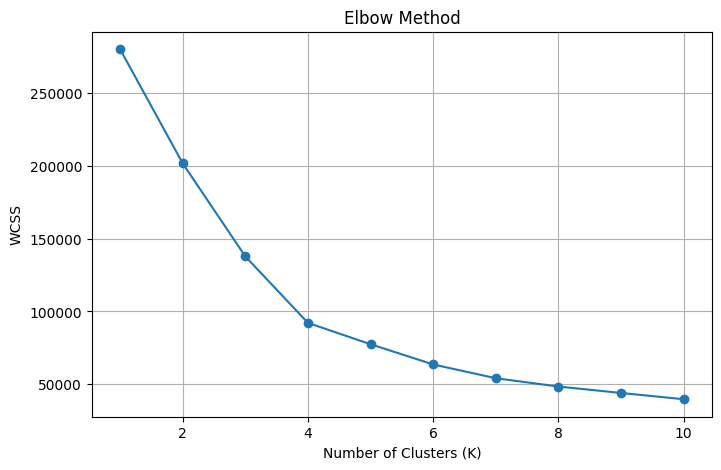

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.savefig(
    "../figures/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
print(inertia)

[280074.0000000003, 201659.7264034438, 137742.4136906622, 92099.17035161555, 77435.44178250762, 63551.96317130807, 54085.23585765037, 48393.68199029863, 43958.488013544076, 39670.8394007663]


In [11]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K={k}: {score:.4f}")

K=2: 0.7389
K=3: 0.4560
K=4: 0.4886
K=5: 0.4187
K=6: 0.4370
K=7: 0.4394
K=8: 0.4485
K=9: 0.3898
K=10: 0.3827


In [12]:
plt.savefig(
    "../figures/silhouette_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [13]:
print(silhouette_scores)

[0.7389413038668743, 0.4559658029676103, 0.48860849278699137, 0.41870450946470084, 0.4369710566922809, 0.43943528759888867, 0.4485195568414554, 0.3897894136469181, 0.38272255553518475]


In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [15]:
customer_df["Cluster"].value_counts()

Cluster
3    50642
0    37526
1     2772
2     2418
Name: count, dtype: int64

In [16]:
cluster_profile = customer_df.groupby(
    "Cluster"
)[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "avg_delivery_days",
        "avg_review_score",
        "repeat_purchase"
    ]
].mean()

cluster_profile

,Recency,Frequency,Monetary,avg_delivery_days,avg_review_score,repeat_purchase
Cluster,,,,,,
0,387.408517,1.000000,133.457760,12.483318,4.175572,0.000000
1,220.443723,2.114358,289.680253,11.864325,4.207834,1.000000
2,239.397849,1.012821,1160.906344,14.160050,3.997312,0.011993
3,128.074365,1.000000,134.360030,11.735378,4.151969,0.000000


In [17]:
cluster_names = {
    0: "At-Risk",
    1: "Loyal",
    2: "High-Value",
    3: "New"
}

customer_df["Cluster_Name"] = (
    customer_df["Cluster"]
    .map(cluster_names)
)

In [18]:
cluster_distribution = (
    customer_df["Cluster_Name"]
    .value_counts()
    .reset_index()
)

cluster_distribution.columns = [
    "Segment",
    "Customers"
]

cluster_distribution["Percentage"] = (
    cluster_distribution["Customers"]
    / len(customer_df)
    * 100
)

cluster_distribution

,Segment,Customers,Percentage
0,New,50642,54.244950
1,At-Risk,37526,40.195805
2,Loyal,2772,2.969215
3,High-Value,2418,2.590030


In [19]:
cluster_distribution.to_csv(
    "../tables/cluster_distribution.csv",
    index=False
)

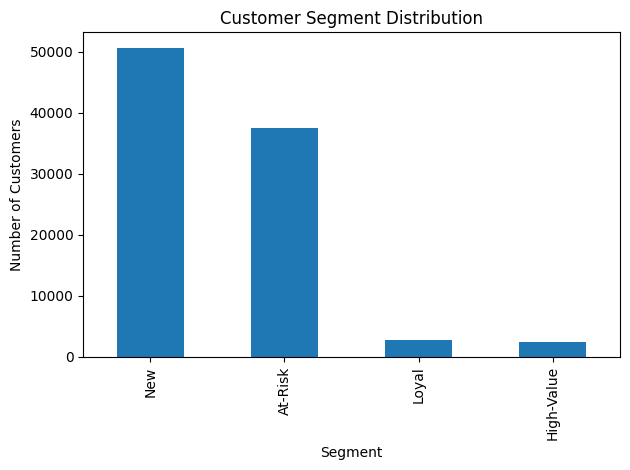

In [20]:
import matplotlib.pyplot as plt

customer_df["Cluster_Name"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../figures/customer_segments.png",
    dpi=300
)

plt.show()

In [21]:
customer_df.to_csv(
    "../data/processed/customer_features_clustered.csv"
)